# Airbnb Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
df = pd.read_csv("airbnb_listings.csv")

# Display first rows
print(df.head())
# Dataset information
print(df.info())

          id                                      name  host_id  \
0  937986014        Private room in Williamsburg #3658  1863403   
1  274900982     Private room in Upper West Side #8936  6017226   
2  630190479             Entire home/apt in SoHo #3583  9791689   
3  391646236  Entire home/apt in Lower East Side #8929  2654753   
4  546101043             Private room in Flatbush #107  5973064   

  neighbourhood_group    neighbourhood        room_type  price  \
0            Brooklyn     Williamsburg     Private room    172   
1           Manhattan  Upper West Side     Private room     31   
2           Manhattan             SoHo  Entire home/apt    169   
3           Manhattan  Lower East Side  Entire home/apt    484   
4            Brooklyn         Flatbush     Private room    194   

   minimum_nights  number_of_reviews  reviews_per_month  availability_365  
0               9                 23               4.60               170  
1               3                 90            

In [3]:
print(df.isnull().sum())

id                     0
name                   0
host_id                0
neighbourhood_group    0
neighbourhood          0
room_type              0
price                  0
minimum_nights         0
number_of_reviews      0
reviews_per_month      0
availability_365       0
dtype: int64


# Drop unnecessary columns

In [4]:
df = df.drop(columns=["id", "host_id", "name"], errors='ignore')

In [5]:
df = df[df['price'] < 500]

# Average price by neighborhood

In [7]:
price_by_neighbourhood = df.groupby('neighbourhood_group')['price'].mean()
print(price_by_neighbourhood)

neighbourhood_group
Bronx            126.426781
Brooklyn         200.872685
Manhattan        257.539914
Queens           161.454787
Staten Island    138.026164
Name: price, dtype: float64


In [8]:
top_reviews = df.sort_values(by='number_of_reviews', ascending=False).head(10)
print(top_reviews[['neighbourhood', 'price', 'number_of_reviews']])

            neighbourhood  price  number_of_reviews
27475        West Village    237                500
17353               DUMBO    173                500
33790          Greenpoint    238                500
12375        East Village    404                500
16051           Bay Ridge    180                500
4095              Jamaica    119                500
7600             Flushing     82                500
7592   University Heights    166                500
1165               Harlem    343                500
17784          Greenpoint     93                500


In [9]:
# Room type distribution
room_counts = df['room_type'].value_counts()
print(room_counts)

room_type
Entire home/apt    20615
Private room       14947
Shared room         2739
Name: count, dtype: int64


# Price by neighborhood

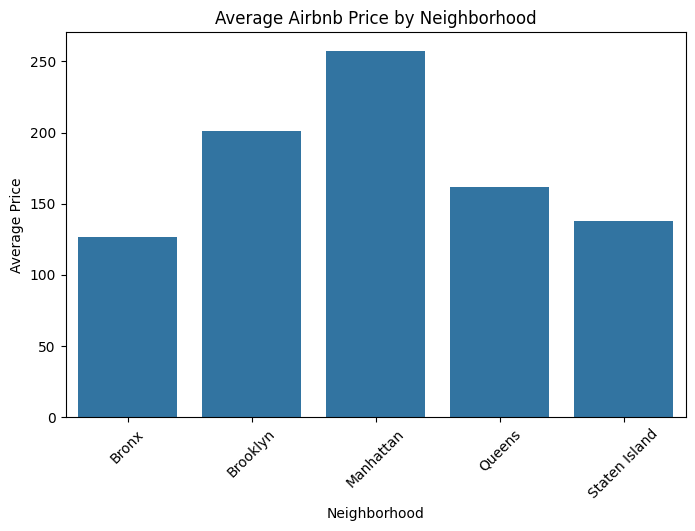

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x=price_by_neighbourhood.index, y=price_by_neighbourhood.values)
plt.title("Average Airbnb Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()


# Room type distribution

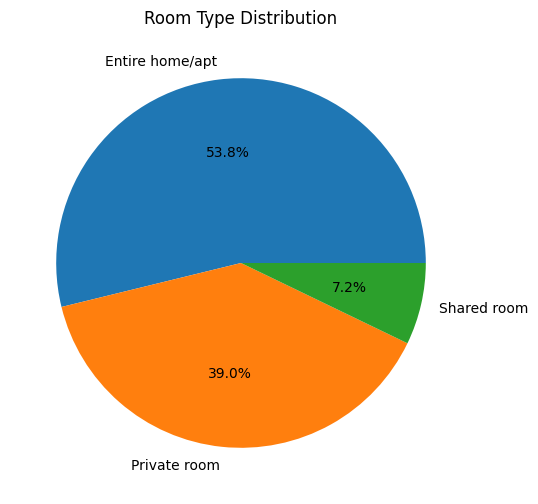

In [11]:
plt.figure(figsize=(6,6))
room_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Room Type Distribution")
plt.ylabel("")
plt.show()